In [1]:
import numpy as np
import scipy
import torch
import torch.nn as nn
from torchdiffeq import odeint as torchodeint
from tqdm import tqdm
import matplotlib.pyplot as plt

import os, sys
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayer import ChebyKAN
from ChebyKANLayer import ChebyKANLayer

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [2]:
model = ChebyKAN([2, 10, 2], 4)

In [4]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.3, 1.5]

In [5]:
kanODE = KANODE(model, pred_prey_deriv, X0, params, 20, 6, 1000)

100%|██████████| 1000/1000 [19:07<00:00,  1.15s/it]


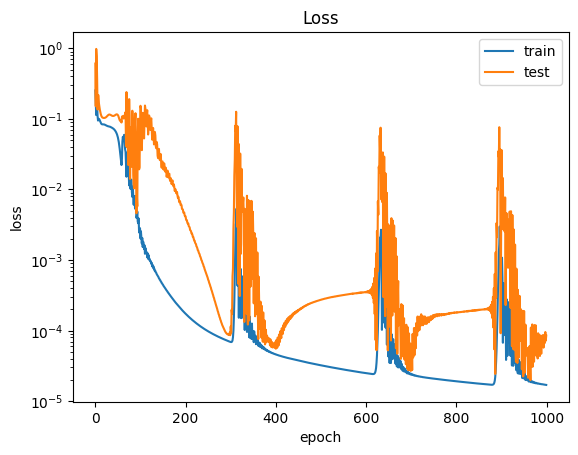

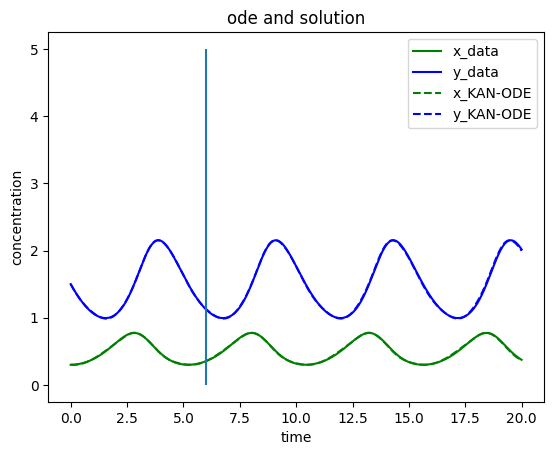

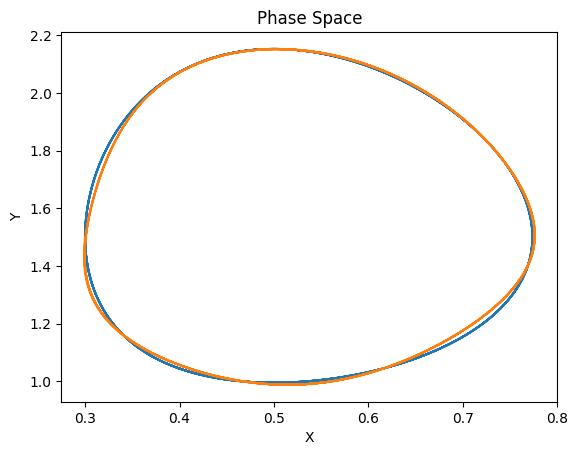

In [6]:
kanODE.train(1000)
_, solution = kanODE.test()
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])

In [8]:
saveDirectory = os.path.join(module_path, "savedModels", "1000Epoch-LV-0p3-1p5-1p5-1-2-1")
model.saveModel(saveDirectory)

In [9]:
model2 = ChebyKAN([2, 10, 2], 4)

100%|██████████| 1/1 [00:00<00:00,  1.40it/s]


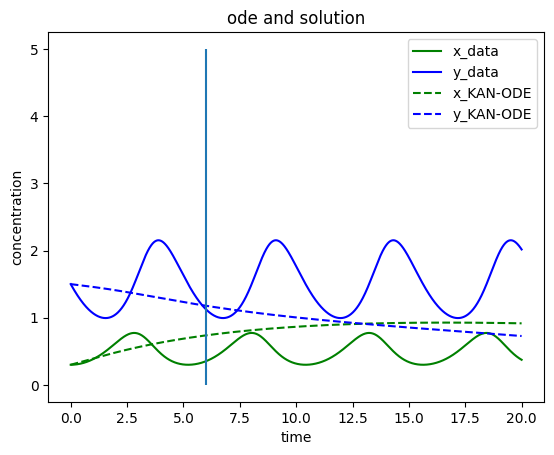

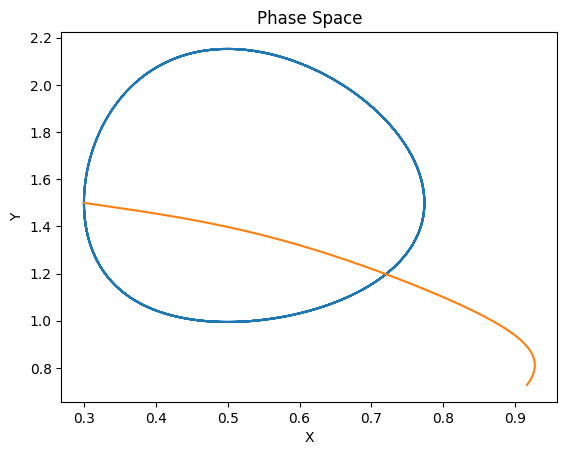

The loss after 1 epoch is : 0.3509650230407715


In [10]:
kanODE.setModel(model2)
kanODE.train(1)
loss, solution = kanODE.test()
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])
print(f"The loss after 1 epoch is : {loss}")

In [11]:
model2.loadModel(saveDirectory)

c:\Users\Adam\Documents\GitHub\KAN-project\KAN_variants\ChebyKANLayer.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.layers[index].cheby_coeffs = torch.load(fileP

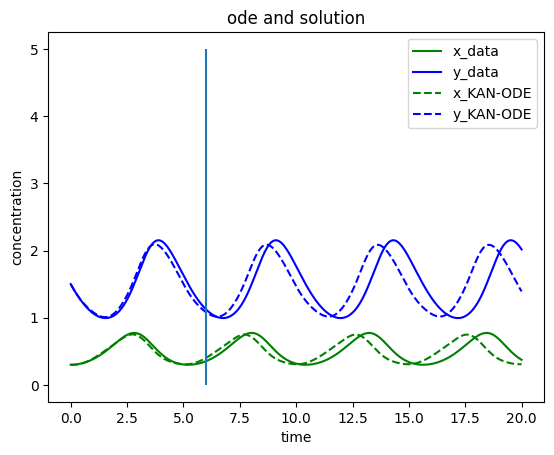

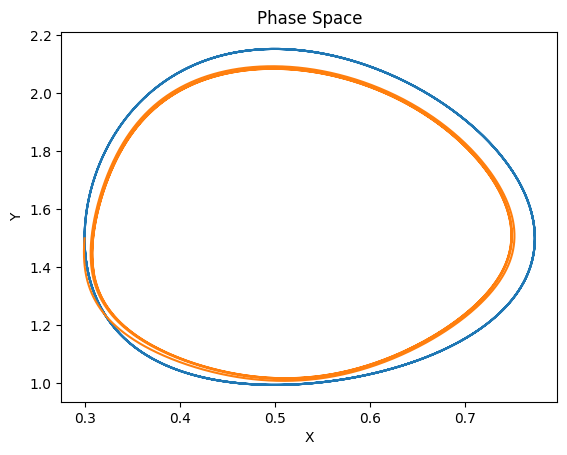

The loss after 1 epoch is : 0.059546053409576416


In [ ]:
loss, solution = kanODE.test()
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])
print(f"The loss after 1 epoch is : {loss}")

Between saving and loading the model there seems to be compression that is having a large effect on the performance of the model. This needs to be investigated still. If the method of saving and loading is the issue I will code an alternate way where I save to a txt file manually instead, where each row pair will contain the layer shape and then weights. Need to check wether the loaded weights are the same as the saved ones. Then that the saved ones are the same as the optimised ones.